# <span style="color: #7c3aed; font-weight: 800;">Day 3 — Backpropagation, Gradient Descent & Optimizers</span>

## <span style="color: #2563eb; font-weight: 700;">Learning Objectives</span>

By the end of this Notebook, I will be able to:

- Describe the four-step training loop of a neural network.
- Explain gradient descent and the role of the learning rate.
- Explain backpropagation conceptually and the role of the chain rule.
- Understand optimizers such as SGD and Adam.
- Explain epochs and batches.
- Compare different learning rates using loss curves.

## <span style="color: #2563eb; font-weight: 700;">Import Libraries</span>

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


## <span style="color: #2563eb; font-weight: 700;">The Neural Network Training Loop</span>

Training a neural network is an iterative process that repeats over the training data.
The four main steps are:
1. **Forward Pass** — The input data passes through the network to produce predictions.
2. **Loss Calculation** — The predictions are compared with the true values to measure the error.
3. **Backpropagation** — The gradients of the loss with respect to the model weights are calculated.
4. **Weight Update** — The optimizer uses the gradients to update the weights and reduce the loss.
The process is repeated for multiple batches and epochs until the model learns useful patterns from the data.
### <span style="color: #0f766e; font-weight: 700;">Training Loop</span>
Forward Pass-->Calculate Loss-->Backpropagation-->Update Weights-->Repeat

## <span style="color: #2563eb; font-weight: 700;">Gradient Descent</span>

Gradient descent is an optimization method used to minimize the loss function.

The gradient tells us the direction in which the loss increases most rapidly. Therefore, gradient descent updates the model weights in the opposite direction of the gradient to reduce the loss.

The general update rule is:

**new weight = old weight - learning rate × gradient**

The learning rate controls how large each update step is.

The goal is to gradually move toward a point where the loss is minimized.

## <span style="color: #2563eb; font-weight: 700;">Learning Rate</span>

The learning rate determines the size of the steps taken when updating the model weights.

- **Very high learning rate:** The model may overshoot the minimum and the loss can become unstable.
- **Very low learning rate:** The model learns very slowly.
- **Suitable learning rate:** The loss usually decreases steadily and training becomes more efficient.

In this experiment, I will compare three different learning rates to observe their effect on training.

## <span style="color: #2563eb; font-weight: 700;">Create a Tiny Dataset</span>

In [3]:
np.random.seed(42)
tf.random.set_seed(42)
X = np.random.randn(1000, 2)
y = ((X[:, 0] + X[:, 1]) > 0).astype(np.float32)
print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", np.unique(y))

Input shape: (1000, 2)
Target shape: (1000,)
Classes: [0. 1.]


## <span style="color: #2563eb; font-weight: 700;">Visualize the Dataset</span>

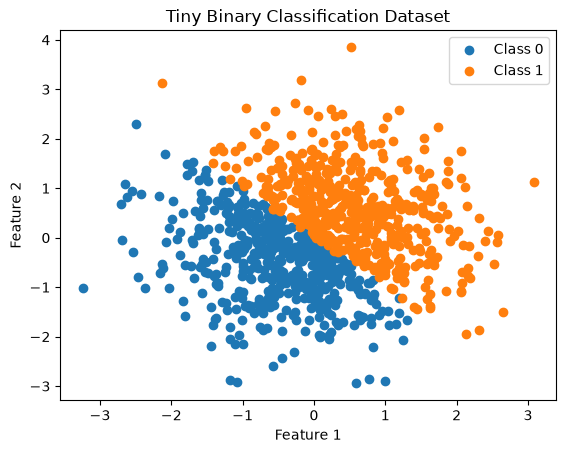

In [4]:
plt.scatter(X[y == 0, 0],X[y == 0, 1],label="Class 0")
plt.scatter(X[y == 1, 0],X[y == 1, 1],label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Tiny Binary Classification Dataset")
plt.legend()
plt.show()

## <span style="color: #2563eb; font-weight: 700;">Train-Test Split</span>

The dataset is divided into training and testing sets.
The training data is used to learn the model parameters, while the testing data is kept separate to evaluate the trained model.
Using a separate test set helps us evaluate how well the model generalizes to unseen data.

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 600
Validation samples: 200
Testing samples: 200


## <span style="color: #2563eb; font-weight: 700;">Build a Tiny Neural Network</span>

I will use a small neural network with:

- Input layer with 2 features
- One hidden layer
- ReLU activation
- One output neuron
- Sigmoid activation for binary classification

The model will be trained multiple times using different learning rates.

In [6]:
def create_model(learning_rate):
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=(2,)),tf.keras.layers.Dense(8, activation="relu"),tf.keras.layers.Dense(1, activation="sigmoid")])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,loss="binary_crossentropy",metrics=["accuracy"])
    return model

## <span style="color: #2563eb; font-weight: 700;">Epochs and Batches</span>
An **epoch** represents one complete pass through the entire training dataset.
A **batch** is a smaller subset of the training data processed before the model updates its weights.
For example, with 600 training samples and a batch size of 32, the model processes the data in smaller groups instead of using all samples at once.
In this experiment:
- Epochs = 50
- Batch size = 32

## <span style="color: #2563eb; font-weight: 700;">Learning Rate Experiment</span>

To understand the effect of the learning rate, I will train the same neural network using three different learning rates:

- **Too Low:** 0.00001
- **Good:** 0.001
- **High:** 10.0

The same dataset, architecture, number of epochs, and batch size will be used so that the main difference between experiments is the learning rate.
**Evaluation protocol:** Training data is used to fit the model, validation data is used to compare learning rates, and the held-out test data is used only in the final evaluation.


In [7]:
learning_rates = {"Too Low": 0.00001,"Good": 0.001,"Too High": 10.0}
histories = {}
for name, lr in learning_rates.items():
    print(f"Training with learning rate = {lr}")
    model = create_model(lr)
    history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_val, y_val),verbose=0)

    histories[name] = history

Training with learning rate = 1e-05
Training with learning rate = 0.001
Training with learning rate = 10.0


## <span style="color: #2563eb; font-weight: 700;">Plot Loss Curves</span>
The loss curves show how the model's error changes during training.
A well-chosen learning rate should generally produce a stable decrease in loss.

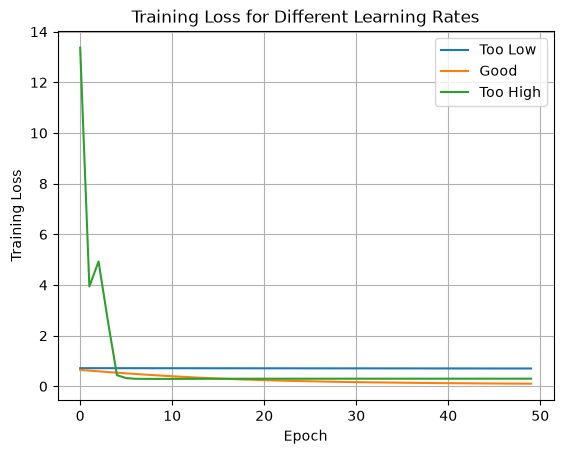

In [8]:
for name, history in histories.items():
    plt.plot(history.history["loss"],label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

## <span style="color: #2563eb; font-weight: 700;">Plot Validation Loss</span> 

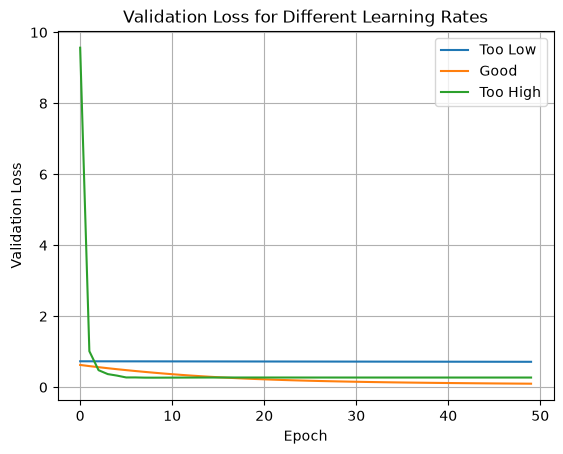

In [9]:
for name, history in histories.items():
    plt.plot(history.history["val_loss"],label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

## <span style="color: #2563eb; font-weight: 700;">Compare Final Results</span>

In [19]:
for name, history in histories.items():
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]
    final_train_accuracy = history.history["accuracy"][-1]
    final_val_accuracy = history.history["val_accuracy"][-1]

    print(f"\n{name}")
    print(f"Learning Rate: {learning_rates[name]}")
    print(f"Final Training Loss: {final_train_loss}")
    print(f"Final Validation Loss: {final_val_loss}")
    print(f"Final Training Accuracy: {final_train_accuracy}")
    print(f"Final Validation Accuracy: {final_val_accuracy}")



Too Low
Learning Rate: 1e-05
Final Training Loss: 0.703868567943573
Final Validation Loss: 0.7157537937164307
Final Training Accuracy: 0.6700000166893005
Final Validation Accuracy: 0.6650000214576721

Good
Learning Rate: 0.001
Final Training Loss: 0.10348322242498398
Final Validation Loss: 0.09864712506532669
Final Training Accuracy: 0.9900000095367432
Final Validation Accuracy: 0.9950000047683716

Too High
Learning Rate: 10.0
Final Training Loss: 0.30175507068634033
Final Validation Loss: 0.27206701040267944
Final Training Accuracy: 0.8500000238418579
Final Validation Accuracy: 0.8600000143051147


### <span style="color: #0f766e; font-weight: 700;">Interpretation of Learning Rate Experiments</span>

The validation-loss curves demonstrate the impact of different learning rates during model selection. The held-out test set is not used in this experiment; it is reserved for the final evaluation section.

- **Too Low (`1e-5`):** The loss decreases very slowly because the update steps are too small to make meaningful progress within the chosen number of epochs.
- **Good (`0.001`):** The loss generally decreases steadily, indicating a suitable step size for this model and dataset.
- **Too High (`10.0`):** The optimizer may take unstable or excessively large steps. With adaptive Adam updates, the exact behavior can vary, so the curve and final validation metrics should be inspected rather than assuming that every run will oscillate dramatically.


## <span style="color: #2563eb; font-weight: 700;">Backpropagation</span>

Backpropagation is the process used to calculate how much each model weight contributed to the final loss.

After the forward pass produces a prediction, the loss function measures the difference between the prediction and the true target.

Backpropagation then works backward through the network and calculates the gradients of the loss with respect to the model parameters.

These gradients tell the optimizer how each parameter should be changed to reduce the loss.

Backpropagation relies on the **chain rule** from calculus because the output of one layer depends on the previous layers.

The chain rule allows the gradient of the final loss to be propagated backward through multiple operations and layers.

In modern deep learning frameworks such as TensorFlow and PyTorch, gradient calculations are performed automatically. Therefore, we normally do not calculate all gradients manually.

## <span style="color: #2563eb; font-weight: 700;">Conceptual Example of Backpropagation</span>

Consider the following process:
Input-->Hidden Layer-->Output-->Prediction-->Loss
After calculating the loss, backpropagation moves backward:
Loss-->Output gradients-->Hidden layer gradients-->Input layer gradients
For every trainable weight, the gradient indicates how changing that weight would affect the loss.
The optimizer then uses these gradients to update the weights.
Therefore:
**Forward pass --> find the prediction**

**Loss --> measure the error**

**Backpropagation --> calculate gradients**

**Optimizer --> update weights**

## <span style="color: #2563eb; font-weight: 700;">Observing Gradients with TensorFlow</span>

TensorFlow can automatically calculate gradients using GradientTape.

This allows us to observe the gradients that are calculated during backpropagation.

In [11]:
gradient_model = create_model(0.001)
X_batch = X_train[:32]
y_batch = y_train[:32].reshape(-1, 1)

with tf.GradientTape() as tape:
    predictions = gradient_model(X_batch, training=True)
    loss_fn = tf.keras.losses.BinaryCrossentropy()
    loss = loss_fn(y_batch, predictions)

gradients = tape.gradient(loss, gradient_model.trainable_variables)
print("Loss:", float(loss))

for variable, gradient in zip(gradient_model.trainable_variables, gradients):
    if gradient is not None:
        print(
            variable.name,
            "parameter shape:", variable.shape,
            "gradient shape:", gradient.shape,
            "gradient mean:", float(tf.reduce_mean(gradient)),
            "gradient norm:", float(tf.norm(gradient))
        )


Loss: 0.5774962902069092
kernel parameter shape: (2, 8) gradient shape: (2, 8) gradient mean: -0.03503667935729027 gradient norm: 0.2820844352245331
bias parameter shape: (8,) gradient shape: (8,) gradient mean: -0.03089926391839981 gradient norm: 0.23982757329940796
kernel parameter shape: (8, 1) gradient shape: (8, 1) gradient mean: -0.030349085107445717 gradient norm: 0.22323472797870636
bias parameter shape: (1,) gradient shape: (1,) gradient mean: -0.014107130467891693 gradient norm: 0.014107130467891693


### <span style="color: #0f766e; font-weight: 700;">Code Explanation & Results:</span>
- **`tf.GradientTape()`** records the forward-pass operations so TensorFlow can compute derivatives automatically.
- **Loss Calculation** computes binary cross-entropy for one batch of examples.
- **Gradient Extraction** uses `tape.gradient()` to calculate the derivative of the loss with respect to every trainable parameter.
- **Results Interpretation** reports the loss, parameter shapes, gradient shapes, gradient means, and gradient norms. Matching parameter and gradient shapes confirm that every trainable parameter has a corresponding gradient for the update step.


## <span style="color: #2563eb; font-weight: 700;">Optimizers: SGD vs Adam</span>

An optimizer is responsible for applying the gradients and updating the model weights.

### <span style="color: #0f766e; font-weight: 700;">SGD</span>

Stochastic Gradient Descent is a basic optimization algorithm that updates the weights using the calculated gradients.

### <span style="color: #0f766e; font-weight: 700;">Adam</span>

Adam is a more adaptive optimizer that adjusts the updates using information from previous gradients.
Adam is often a strong default choice for neural network training because it usually provides stable and efficient optimization with less manual tuning.
In this notebook, Adam is used for the main learning-rate experiment.

### <span style="color: #0f766e; font-weight: 700;">Compare SGD and Adam</span>

In [12]:
def create_optimizer_model(optimizer):
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=(2,)),tf.keras.layers.Dense(8, activation="relu"),tf.keras.layers.Dense(1, activation="sigmoid")])
    model.compile(optimizer=optimizer,loss="binary_crossentropy",metrics=["accuracy"])
    return model

In [13]:
tf.keras.utils.set_random_seed(42)
optimizer_learning_rate = 0.001
sgd_model = create_optimizer_model(
    tf.keras.optimizers.SGD(learning_rate=optimizer_learning_rate)
)

# Reset the seed so both models start from the same initialization.
tf.keras.utils.set_random_seed(42)
adam_model = create_optimizer_model(
    tf.keras.optimizers.Adam(learning_rate=optimizer_learning_rate)
)

sgd_history = sgd_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)
adam_history = adam_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)


### <span style="color: #0f766e; font-weight: 700;">Plot SGD vs Adam</span>

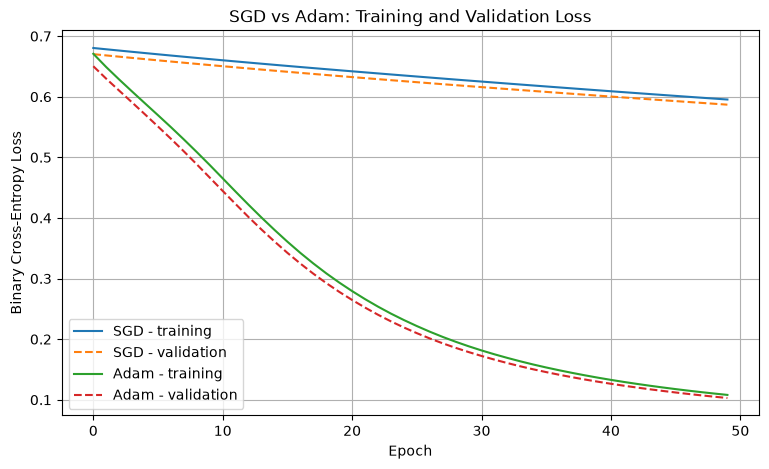

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(sgd_history.history["loss"], label="SGD - training")
plt.plot(sgd_history.history["val_loss"], label="SGD - validation", linestyle="--")
plt.plot(adam_history.history["loss"], label="Adam - training")
plt.plot(adam_history.history["val_loss"], label="Adam - validation", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("SGD vs Adam: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


### <span style="color: #0f766e; font-weight: 700;">Optimizer Comparison — Interpretation</span>

Both SGD and Adam use gradients to update the neural-network weights. SGD applies a basic update using the current gradient, while Adam adapts the update using moving estimates of past gradients.

This comparison uses the **same learning rate (`0.001`)**, the same architecture, the same data split, the same batch size, and the same random initialization. This makes the comparison more meaningful because the optimizer is the main changing factor.

The dashed curves represent validation loss. A useful optimizer should reduce training loss while also keeping validation loss low and stable. Adam is often a strong default because it can converge efficiently with less manual tuning, but the final decision should be based on both the curves and the numeric results below.


In [18]:
optimizer_results = {
    "SGD": {
        "final_train_loss": sgd_history.history["loss"][-1],
        "final_val_loss": sgd_history.history["val_loss"][-1],
        "final_train_accuracy": sgd_history.history["accuracy"][-1],
        "final_val_accuracy": sgd_history.history["val_accuracy"][-1],
    },
    "Adam": {
        "final_train_loss": adam_history.history["loss"][-1],
        "final_val_loss": adam_history.history["val_loss"][-1],
        "final_train_accuracy": adam_history.history["accuracy"][-1],
        "final_val_accuracy": adam_history.history["val_accuracy"][-1],
    },
}

print(f"{'Optimizer':<12} {'Train Loss':>12} {'Val Loss':>12} {'Train Acc.':>12} {'Val Acc.':>12}")
for name, result in optimizer_results.items():
    print(
        f"{name:<12} "
        f"{result['final_train_loss']:>12} "
        f"{result['final_val_loss']:>12} "
        f"{result['final_train_accuracy']:>12} "
        f"{result['final_val_accuracy']:>12}"
    )


Optimizer      Train Loss     Val Loss   Train Acc.     Val Acc.
SGD          0.5954151153564453 0.586926281452179 0.596666693687439 0.6100000143051147
Adam         0.1080423891544342 0.10295607894659042 0.9850000143051147          1.0


## <span style="color: #2563eb; font-weight: 700;">Final Evaluation</span>

In [17]:
final_test_results = {}

for name, lr in learning_rates.items():
    model = create_model(lr)
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    final_test_results[name] = {
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }
    print(
        f"{name}: Test Loss = {test_loss}, "
        f"Test Accuracy = {test_accuracy}"
    )


Too Low: Test Loss = 0.6913294196128845, Test Accuracy = 0.4000000059604645
Good: Test Loss = 0.2405472993850708, Test Accuracy = 0.949999988079071
Too High: Test Loss = 0.6597781181335449, Test Accuracy = 0.7250000238418579


## <span style="color: #7c3aed; font-weight: 800;">Hands-On Lab</span>

### <span style="color: #2563eb; font-weight: 700;">Task 1 — Draw or describe the four-step training loop in a Markdown cell for the project notebook.</span>

**Completed:**

- Forward pass explained.
- Loss calculation explained.
- Backpropagation explained.
- Weight update explained.
- Training loop documented.

#### <span style="color: #2563eb; font-weight: 700;">Task 2 — Experiment with a tiny network at three learning rates (too high, too low, good) and plot the loss curves.
.</span>

**Completed:**

- Low learning rate tested.
- Suitable learning rate tested.
- High learning rate tested.
- Training and validation loss curves compared.
- Learning-rate effects interpreted.
- The test set reserved for final evaluation.

#### <span style="color: #2563eb; font-weight: 700;">Task 3 —  Explain, in your own words, what backpropagation computes and why the chain rule is involved.</span>

**Completed:**

- Backpropagation explained conceptually.
- Gradients explained.
- The role of the chain rule explained.
- TensorFlow `GradientTape` used to observe gradients.
- Gradient shapes inspected for all trainable parameters.
- Gradient means and gradient norms inspected.
#### <span style="color: #2563eb; font-weight: 700;">Task 4 — Open a Pull Request for the mid-sprint Mentor Code & Notebook Review and address the feedback.</span>


Completed:

- Pull Request created for the Day 3 notebook.
- Notebook submitted for mentor review.
- Final notebook changes pushed to the branch.
- Mentor feedback will be addressed when received.



## <span style="color: #2563eb; font-weight: 700;">Summary of the Day</span>

Today, I learned how neural networks train through:

- Forward pass, loss calculation, backpropagation, and weight updates.
- The effect of different learning rates on training.
- How backpropagation calculates gradients using the chain rule.
- How SGD and Adam update model weights.
- The role of epochs and batches in training.